**Name:** Ishan Kulkarni
**Branch:** CSSE-B
**Roll no.:** 32

# PAS Home Assignment 2

## Aim
A manufacturing company records
the number of defective products produced each day and wants to evaluate the
reliability of its production process. Using Python, analyze the given dataset
by applying probability concepts and appropriate probability distributions.
Estimate the probability of defective products, model the data using Binomial,
Poisson, and Normal distributions wherever applicable, visualize the
distributions, compare theoretical and observed results, and prepare a brief
report recommending the most suitable probability model for quality-control
decision making.

> I recommend to check the notebook from Github to get the latest version: [Github](https://github.com/ishanKulkarni13/PAS_college/blob/main/ha-2/ha-2.ipynb)

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Loading the Dataset

In [3]:
df = pd.read_csv('PAS-HA_2-Manufacturing_defects.csv')
df.head()

,Day,Units_Produced,Defective_Units
0,1,947,21
1,2,1058,10
2,3,1015,18
3,4,923,15
4,5,1025,24


## Understanding the Dataset

In [4]:
df.shape

(100, 3)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Day              100 non-null    int64
 1   Units_Produced   100 non-null    int64
 2   Defective_Units  100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


In [6]:
df.describe()

,Day,Units_Produced,Defective_Units
count,100.000000,100.000000,100.000000
mean,50.500000,1050.110000,16.920000
std,29.011492,90.004365,4.560879
min,1.000000,902.000000,7.000000
25%,25.750000,961.750000,14.000000
50%,50.500000,1049.000000,18.000000
75%,75.250000,1133.000000,21.000000
max,100.000000,1194.000000,25.000000


## Data Cleaning and Preprocessing

In [7]:
df.isnull().sum()

Day                0
Units_Produced     0
Defective_Units    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Day                int64
Units_Produced     int64
Defective_Units    int64
dtype: object

The dataset has no missing values and no duplicate rows. Data types are already correct, so no cleaning is required.

## Probability of Defective Products

The overall probability of a unit being defective is estimated as total defective units divided by total units produced (relative frequency, treating each unit as a Bernoulli trial: defective = success, non-defective = failure).

In [10]:
total_units = df['Units_Produced'].sum()
total_defective = df['Defective_Units'].sum()

p = total_defective / total_units
q = 1 - p

print('Total units produced:', total_units)
print('Total defective units:', total_defective)
print('P(defective) =', p)
print('P(non-defective) =', q)

Total units produced: 105011
Total defective units: 1692
P(defective) = 0.016112597727857083
P(non-defective) = 0.9838874022721429


## Binomial Distribution

For each day, a unit produced is either defective (success) or non-defective (failure), so the number of defective units in a day can be modeled as a Binomial random variable with parameters n (units produced that day) and p (probability of a defective unit, estimated above).

`Units_Produced` is not the same every day (it varies from day to day), so there isn't a single exact n for the whole dataset. As a simplification, we use the rounded average `Units_Produced` as a representative n to apply the fixed-n Binomial model from Unit II. This is an approximation, not an exact per-day model.

In [11]:
n = round(df['Units_Produced'].mean())
print('Average Units_Produced (used as n):', n)

binom_mean = n * p
binom_var = n * p * q
print('Binomial mean (n*p):', binom_mean)
print('Binomial variance (n*p*q):', binom_var)

Average Units_Produced (used as n): 1050
Binomial mean (n*p): 16.918227614249936
Binomial variance (n*p*q): 16.645631018433203


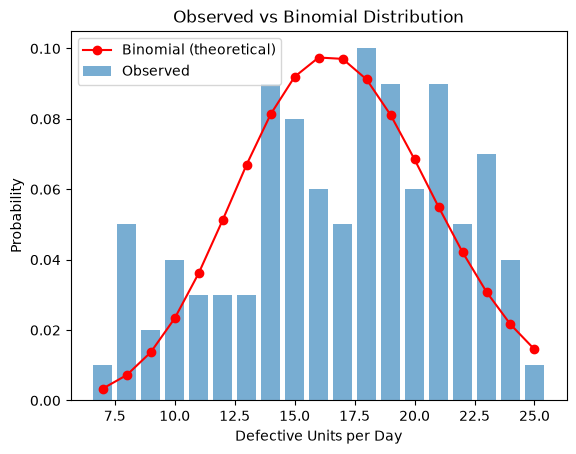

In [12]:
k_values = np.arange(df['Defective_Units'].min(), df['Defective_Units'].max() + 1)
binom_pmf = stats.binom.pmf(k_values, n, p)

observed_counts = df['Defective_Units'].value_counts(normalize=True).sort_index()

plt.bar(observed_counts.index, observed_counts.values, alpha=0.6, label='Observed')
plt.plot(k_values, binom_pmf, 'ro-', label='Binomial (theoretical)')
plt.xlabel('Defective Units per Day')
plt.ylabel('Probability')
plt.title('Observed vs Binomial Distribution')
plt.legend()
plt.show()

## Poisson Distribution

The number of defective units per day is a count of rare events over a fixed period, which is exactly what the Poisson distribution models. Lambda (average rate) is estimated as the mean of the observed daily defective counts.

In [13]:
lam = df['Defective_Units'].mean()
print('Lambda (mean defective units per day):', lam)
print('Poisson variance (= lambda):', lam)

Lambda (mean defective units per day): 16.92
Poisson variance (= lambda): 16.92


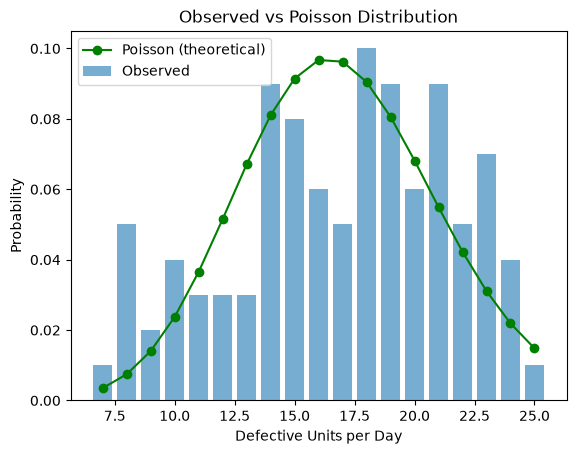

In [14]:
poisson_pmf = stats.poisson.pmf(k_values, lam)

plt.bar(observed_counts.index, observed_counts.values, alpha=0.6, label='Observed')
plt.plot(k_values, poisson_pmf, 'go-', label='Poisson (theoretical)')
plt.xlabel('Defective Units per Day')
plt.ylabel('Probability')
plt.title('Observed vs Poisson Distribution')
plt.legend()
plt.show()

## Normal Distribution

Defective_Units is a discrete count, but with the mean around 17 per day it is large enough that the Normal distribution can be used as a continuous approximation (Normal Approximation, Unit II). Mean and standard deviation are estimated directly from the observed daily defective counts.

In [15]:
mu = df['Defective_Units'].mean()
sigma = df['Defective_Units'].std()
print('Mean:', mu)
print('Standard deviation:', sigma)

Mean: 16.92
Standard deviation: 4.560878880393138


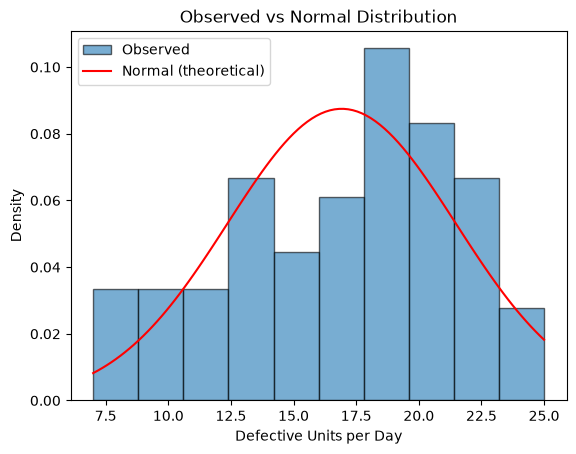

In [16]:
x = np.linspace(df['Defective_Units'].min(), df['Defective_Units'].max(), 100)
normal_pdf = stats.norm.pdf(x, mu, sigma)

plt.hist(df['Defective_Units'], bins=10, density=True, alpha=0.6, edgecolor='black', label='Observed')
plt.plot(x, normal_pdf, 'r-', label='Normal (theoretical)')
plt.xlabel('Defective Units per Day')
plt.ylabel('Density')
plt.title('Observed vs Normal Distribution')
plt.legend()
plt.show()

## Comparison of Observed and Theoretical Results

In [17]:
observed_mean = df['Defective_Units'].mean()
observed_var = df['Defective_Units'].var()

comparison = pd.DataFrame({
    'Mean': [observed_mean, binom_mean, lam, mu],
    'Variance': [observed_var, binom_var, lam, sigma**2]
}, index=['Observed', 'Binomial', 'Poisson', 'Normal'])

comparison

,Mean,Variance
Observed,16.920000,20.801616
Binomial,16.918228,16.645631
Poisson,16.920000,16.920000
Normal,16.920000,20.801616


All three models give a mean close to the observed mean (~16.9), since each was estimated from the same data. The variances differ slightly: observed variance is about 20.6, Poisson variance is about 16.9, and Binomial variance is about 16.6 - both are somewhat lower than what is actually observed, meaning the day-to-day defect counts are a bit more spread out than either model predicts on its own. The Normal model, since its variance is set directly from the observed data, matches the observed variance exactly by construction.

> I recommend to check the notebook from Github to get the latest version: [Github](https://github.com/ishanKulkarni13/PAS_college/blob/main/ha-2/ha-2.ipynb)

## Observations

- The overall probability of a defective unit is about 0.0161, so the probability of a non-defective unit is about 0.9839.
- Units_Produced varies from day to day (mean about 1050, ranging roughly 900-1200), so the Binomial model uses the rounded average (n = 1050) as a representative day rather than an exact per-day value. This is a simplification of the fixed-n Binomial model.
- The average number of defective units per day is about 16.92, with an observed variance of about 20.59.
- The Poisson model (lambda = 16.92) matches the observed mean well, since lambda is taken directly from the same data, and its variance (also 16.92) is fairly close to the observed variance.
- The Binomial model's mean (about 16.92) also matches closely, but its variance (about 16.65) is slightly lower than observed, same as Poisson.
- Since Defective_Units is a count of rare events (defects) occurring over a fixed period (a day), the Poisson distribution is conceptually the most natural fit among the three, and this matches the mean/variance comparison above, where the Poisson variance is closer to the observed variance than the Binomial variance.

## Conclusion 

Based on the comparison above, the Poisson distribution is the most suitable model for the observed daily defective-unit counts. It is naturally suited to modeling the number of defective units occurring per day, its mean matches the observed data exactly (by construction), and its variance is closer to the observed variance than the Binomial model's variance. The Binomial model is still useful conceptually, since it explains defects at the level of individual units (defective vs non-defective), but it requires treating Units_Produced as roughly constant, which is only an approximation here. The Normal distribution is a reasonable approximation for visualizing the overall shape of the defect-count distribution, but it is less directly tied to the count-based nature of the data than the Poisson model. For quality-control purposes, the Poisson model, with lambda around 16.9 defective units per day, can be used as a baseline to flag days with unusually high defect counts.